# Bidirectional `RNNs` `LSTMs` `GRUs`

# Import Libraries

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [54]:
from sklearn.model_selection import train_test_split

In [55]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization
from tensorflow.keras.layers import Embedding, LSTM, GRU, Bidirectional, SimpleRNN

In [56]:
import kagglehub
import os
import re

# Data Load

In [57]:
path = kagglehub.dataset_download("jackksoncsie/spam-email-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'spam-email-dataset' dataset.
Path to dataset files: /kaggle/input/spam-email-dataset


In [58]:
print("Contents of the dataset directory:")
for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

Contents of the dataset directory:
/kaggle/input/spam-email-dataset/emails.csv


In [59]:
df = pd.read_csv(os.path.join(path, "emails.csv"))
df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [60]:
df.shape

(5728, 2)

# Max Length

In [61]:
col = 'text'
max_len_index = df[col].str.len().idxmax()
max_length = df[col].str.len().max()
longest_string = df[col].loc[max_len_index]

print("Longest:", longest_string)
print("Length:", len(longest_string))
print(f'Max Length {max_length}')

Longest: Subject: from the enron india newsdesk - april 27 th newsclips  fyi news articles from indian press .  - - - - - - - - - - - - - - - - - - - - - - forwarded by sandeep kohli / enron _ development on 04 / 27 / 2001 08 : 24 am - - - - - - - - - - - - - - - - - - - - - - - - - - -  nikita varma  04 / 27 / 2001 07 : 51 am  to : nikita varma / enron _ development @ enron _ development  cc : ( bcc : sandeep kohli / enron _ development )  subject : from the enron india newsdesk - april 27 th newsclips  friday apr 27 2001 , http : / / www . economictimes . com / today / cmo 3 . htm  dpc board empowers md to cancel mseb contract  friday apr 27 2001 , http : / / www . economictimes . com / today / 27 compl 1 . htm  mseb pays rs 134 cr under ' protest ' to dpc  friday , april 27 , 001 , http : / / www . businessstandard . com / today / economy 4 . asp ? menu = 3  enron india md authorised to terminate ppa  friday , april 27 , 2001 , http : / / www . financialexpress . com / fe 20010427 /

In [62]:
top10 = df.assign(length=df['text'].str.len()) \
          .sort_values('length', ascending=False) \
          .head(3500)

print(top10[['text', 'length']])


                                                   text  length
2650  Subject: from the enron india newsdesk - april...   43952
1380  Subject: from the enron india newsdesk - april...   43937
2338  Subject: from the enron india newsdesk - april...   31055
536   Subject: make thousands just sending emails . ...   28432
2560  Subject: from the enron india newsdesk - may 5...   27965
...                                                 ...     ...
307   Subject: visual identity and logo now  working...     749
340   Subject: impress your girl with a huge cumshot...     749
811   Subject: entrust your visual identity to us  t...     749
5478  Subject: re : ed krapels  absolutely - i can '...     749
2079  Subject: actuarial course material  hi dale , ...     749

[3500 rows x 2 columns]


## Remove These

In [63]:
# Find top 100 longest texts
top100_indices = df['text'].str.len().sort_values(ascending=False).head(3500).index

# Remove them
df_clean = df.drop(index=top100_indices).reset_index(drop=True)

print("Original size:", len(df))
print("New size:", len(df_clean))
df.head()

Original size: 5728
New size: 2228


,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


# Text Preprocessing

## Make Lower Case

In [64]:
df_clean.text = df_clean.text.str.lower()
df_clean.head()

,text,spam
0,subject: the stock trading gunslinger fanny i...,1
1,subject: unbelievable new homes made easy im ...,1
2,subject: 4 color printing special request add...,1
3,"subject: do not have money , get software cds ...",1
4,"subject: great nnews hello , welcome to medzo...",1


## Remove Unnecessery Character

In [65]:
df_clean['text'] = df_clean['text'].apply(lambda x: re.sub(r'[^A-Za-z0-9 ]+', '', x))
df_clean.head()

,text,spam
0,subject the stock trading gunslinger fanny is...,1
1,subject unbelievable new homes made easy im w...,1
2,subject 4 color printing special request addi...,1
3,subject do not have money get software cds fr...,1
4,subject great nnews hello welcome to medzonl...,1


## Tokenized Test

In [66]:
max_len = df_clean['text'].str.len().max()
max_len

728

In [67]:
tokenizer = Tokenizer(oov_token="undefine")
tokenizer.fit_on_texts(df_clean["text"])

## Sequences

In [68]:
x = tokenizer.texts_to_sequences(df_clean["text"])
y = df_clean["spam"]
print(f"Number of sequences: {len(x)}")
print(f"Length of sequence: {len(x[0])}")

Number of sequences: 2228
Length of sequence: 89


In [69]:
# Check Sequence data
nx = 156
print("Tokenized length:", len(x[nx]))
print("Original word count:", len(df_clean['text'][nx].split()))
print("Original text:", df_clean['text'][nx])
print("Tokenized seq:", x[nx])

Tokenized length: 99
Original word count: 99
Original text: subject localized software  all languages available   hello  we would like to offer localized software versions  german  french  spanish  uk  and many others    ali iisted software is avaiiabie for immediate download   no need to wait 2  3 week for cd delivery   just few examples    norton lnternet security pro 2005   29  95   windows xp professionai with sp 2 fuli version   59  95   corel draw graphics suite 12   49  95   dreamweaver mx 2004  homesite 5  5 inciudinq    39  95   macromedia studio mx 2004   119  95  just browse our site and find any software you need in your native lanquage   best regards   margarette 
Tokenized seq: [5, 389, 85, 52, 777, 174, 121, 17, 38, 49, 3, 170, 389, 85, 778, 1411, 779, 720, 423, 6, 247, 495, 2752, 1219, 85, 11, 2426, 9, 780, 607, 88, 60, 3, 477, 53, 62, 115, 9, 578, 341, 64, 202, 958, 721, 1404, 438, 680, 415, 305, 146, 657, 754, 1040, 19, 722, 53, 2441, 244, 428, 146, 1181, 723, 724, 60

In [70]:
tokenizer.word_index['wanna']

2782

## Add Padding

In [71]:
max_len

728

In [72]:
X = pad_sequences(sequences=x, maxlen=max_len, padding="post")
X.shape

(2228, 728)

# Train Test Split

In [73]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((1782, 728), (446, 728))

# Bidirectional `RNNs`

In [76]:
rnns_model = Sequential(
    [
        Input((max_len,)),
        Embedding(len(tokenizer.word_index)+1, 8),

        Bidirectional(SimpleRNN(8, return_sequences=True)),
        Bidirectional(SimpleRNN(8)),

        Dense(1, activation="sigmoid")
    ]
)

rnns_model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
rnns_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 728, 8)         │       105,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_10                │ (None, 728, 16)        │           272 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_11                │ (None, 16)             │           400 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,705 (412.91 KB)

 Trainable params: 105,705 (412.91 KB)

 Non-trainable params: 0 (0.00 B)

In [77]:
history1 = rnns_model.fit(
    x=X_train,
    y=y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=64
)

Epoch 1/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 14s 308ms/step - accuracy: 0.5893 - loss: 0.6595 - val_accuracy: 0.7108 - val_loss: 0.5714
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 171ms/step - accuracy: 0.8046 - loss: 0.4637 - val_accuracy: 0.7668 - val_loss: 0.5404
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 177ms/step - accuracy: 0.9351 - loss: 0.3199 - val_accuracy: 0.7915 - val_loss: 0.4985
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 171ms/step - accuracy: 0.9811 - loss: 0.2063 - val_accuracy: 0.7982 - val_loss: 0.4901
Epoch 5/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 174ms/step - accuracy: 0.9869 - loss: 0.1529 - val_accuracy: 0.7915 - val_loss: 0.4961
Epoch 6/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 174ms/step - accuracy: 0.9945 - loss: 0.1107 - val_accuracy: 0.7870 - val_loss: 0.5096
Epoch 7/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 171ms/step - accuracy: 0.9967 - loss: 0.0909 - val_accuracy: 0.7399 - val_loss: 0.5774
Epoch 8/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 182ms/step - accuracy: 0.9997 - loss: 0.0685 - val_accuracy: 0

# Bidirectional `LSTM`

In [78]:
lstm_model = Sequential(
    [
        Input((max_len,)),
        Embedding(len(tokenizer.word_index)+1, 8),

        Bidirectional(LSTM(8, return_sequences=True)),
        Bidirectional(LSTM(8)),

        Dense(1, activation="sigmoid")
    ]
)

lstm_model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
lstm_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 728, 8)         │       105,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_12                │ (None, 728, 16)        │         1,088 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_13                │ (None, 16)             │         1,600 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 107,721 (420.79 KB)

 Trainable params: 107,721 (420.79 KB)

 Non-trainable params: 0 (0.00 B)

In [79]:
history2 = lstm_model.fit(
    x=X_train,
    y=y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=64
)

Epoch 1/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 104ms/step - accuracy: 0.6593 - loss: 0.6619 - val_accuracy: 0.6480 - val_loss: 0.6304
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - accuracy: 0.7068 - loss: 0.5481 - val_accuracy: 0.6480 - val_loss: 0.4612
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - accuracy: 0.8281 - loss: 0.3686 - val_accuracy: 0.9552 - val_loss: 0.3020
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - accuracy: 0.9525 - loss: 0.2634 - val_accuracy: 0.9798 - val_loss: 0.2076
Epoch 5/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.9840 - loss: 0.1771 - val_accuracy: 0.9865 - val_loss: 0.1596
Epoch 6/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - accuracy: 0.9942 - loss: 0.1335 - val_accuracy: 0.9641 - val_loss: 0.1693
Epoch 7/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - accuracy: 0.9873 - loss: 0.1184 - val_accuracy: 0.9753 - val_loss: 0.1392
Epoch 8/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - accuracy: 0.9945 - loss: 0.0954 - val_accuracy: 0.991

# Bidirectional `GRU`

In [80]:
gru_model = Sequential(
    [
        Input((max_len,)),
        Embedding(len(tokenizer.word_index)+1, 8),

        Bidirectional(GRU(8, return_sequences=True)),
        Bidirectional(GRU(8)),

        Dense(1, activation="sigmoid")
    ]
)

gru_model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
gru_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, 728, 8)         │       105,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_14                │ (None, 728, 16)        │           864 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_15                │ (None, 16)             │         1,248 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 107,145 (418.54 KB)

 Trainable params: 107,145 (418.54 KB)

 Non-trainable params: 0 (0.00 B)

In [81]:
history3 = gru_model.fit(
    x=X_train,
    y=y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=64
)

Epoch 1/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - accuracy: 0.6803 - loss: 0.6650 - val_accuracy: 0.6480 - val_loss: 0.6448
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - accuracy: 0.6786 - loss: 0.6127 - val_accuracy: 0.6480 - val_loss: 0.6048
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.6971 - loss: 0.5299 - val_accuracy: 0.8117 - val_loss: 0.4049
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.9370 - loss: 0.2869 - val_accuracy: 0.9664 - val_loss: 0.1687
Epoch 5/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - accuracy: 0.9814 - loss: 0.1099 - val_accuracy: 0.9821 - val_loss: 0.0927
Epoch 6/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - accuracy: 0.9895 - loss: 0.0664 - val_accuracy: 0.9821 - val_loss: 0.0752
Epoch 7/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.9937 - loss: 0.0478 - val_accuracy: 0.9664 - val_loss: 0.1155
Epoch 8/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.9952 - loss: 0.0327 - val_accuracy: 0.9731 -

# Bidirectional `RNN` vs `LSTM` vs `GRU` accuracy

## Train

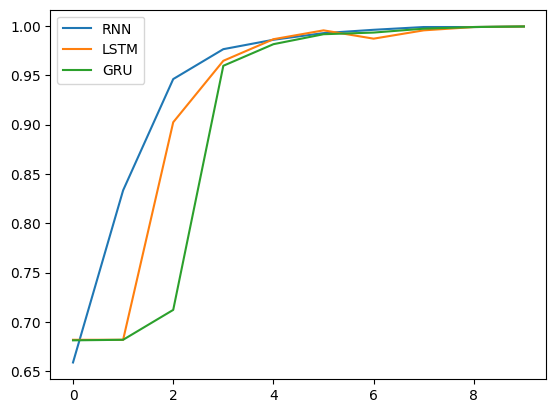

In [82]:
plt.plot(history1.history['accuracy'], label='RNN')
plt.plot(history2.history['accuracy'], label='LSTM')
plt.plot(history3.history['accuracy'], label='GRU')
plt.legend()
plt.show()

## Validation

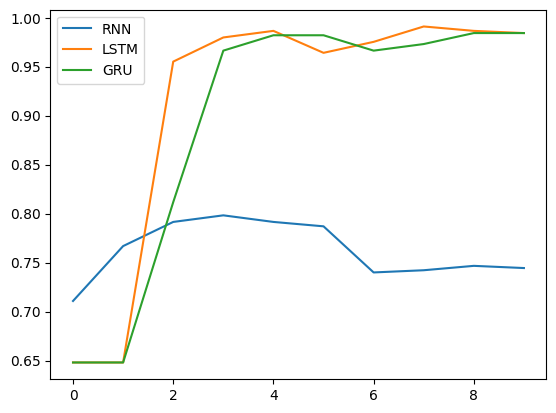

In [83]:
plt.plot(history1.history['val_accuracy'], label='RNN')
plt.plot(history2.history['val_accuracy'], label='LSTM')
plt.plot(history3.history['val_accuracy'], label='GRU')
plt.legend()
plt.show()